# Notebook lecture 3: State Feedback for CS2
&copy; 2026 ETH Zurich, Joël Gmür, Joël Lauper, Niclas Scheuer, Dejan Milojevic; Institute for Dynamic Systems and Control; Prof. Emilio Frazzoli

Authors:
- Joël Gmür; jgmuer@ethz.ch
- Joël Lauper; jlauper@ethz.ch

To start, run the following cell to install the necessary modules and import the libraries.

In [2]:
# Import the required python libraries

import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as linalg
import scipy.signal as signal
import ipywidgets as widgets
from ipywidgets import interactive

## Problem Setup

In this notebook we will use a simple mass-spring-damper system.
The control input is a force per mass $u=\frac{F(t)}{m}$, and the output is the position $x$.

 Setting $\frac{k}{m} = \frac{c}{m} = 1$ and $u=\frac{F(t)}{m}$, the state space description of the system reads:

$$
\begin{bmatrix}\dot{x}_1 \\ \dot{x}_2 \end{bmatrix} =\begin{bmatrix}\dot{x} \\ \ddot{x} \end{bmatrix} = \begin{bmatrix}0 & 1 \\ -1 & -1 \end{bmatrix} \begin{bmatrix} x \\ \dot{x} \end{bmatrix} + \begin{bmatrix}0 \\ 1 \end{bmatrix} u,
$$

$$y = \begin{bmatrix} 1 & 0 \end{bmatrix} \begin{bmatrix} x \\ \dot{x} \end{bmatrix}. $$

In [3]:
# Define the state-space system (mass-spring-damper)
A = np.array([[0, 1],
              [-1, -1]])  # System dynamics
B = np.array([[0], [1]])  # Input matrix
C = np.array([[1, 0]])    # Output matrix (we care about position)
D = np.array([[0]])

## Example 1: Pole placement

Using state feedback, it is now possible to place the poles wherever see fit. Using Ackermann's formula we can directly find a state feedback controller that places the closed-loop poles at the desired position. For a 2x2 $A$ matrix, Ackermann's formula reads as:

$$ K = [0  \ 1] \cdot \mathcal{R}^{-1} \cdot \phi_d(A), $$

where $\mathcal{R}$ is the reachability matrix and $\phi_d$ is the desired characteristic polynomial. In the following code snippet we will define the poles p1 and p2.

In [4]:
I = np.identity(2)

# Function to update the plot based on pole positions
def update_step_response(p1, p2):
    # Compute reachability matrix
    R = np.hstack([B, A @ B])

    # Compute characteristic polynomial
    phi_d = (A - I * p1) @ (A - I * p2)

    # Evaluate state-feedback matrix
    K = np.array([[0, 1]]) @ np.linalg.inv(R) @ phi_d

    # Find the closed-loop matrix
    A_cl = A - B @ K

    if(np.linalg.matrix_rank(A_cl) != 2):
        print("error: singular closed loop matrix!")

    # Compute reference scaling factor
    Kr = np.linalg.inv(-C @ np.linalg.inv(A_cl) @ B)

    # Create state-space system
    system = signal.StateSpace(A_cl, B @ Kr, C, D)

    # Simulating step response
    t = np.linspace(0, 10, 1000)  # Time vector from 0 to 10 sec
    r = np.ones_like(t)  # Step input
    x0 = np.array([0, 0])  # Initial state

    t_out, y, x = signal.lsim(system, U=r, T=t, X0=x0)

    # Compute input
    u = -K @ x.T + Kr * r

    # Plotting
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))

    axs[0].plot(t, y, label="Step Response", color="b")
    axs[0].set_xlabel("Time (s)")
    axs[0].set_ylabel("Response")
    axs[0].set_title("Closed-Loop Step Response")
    axs[0].grid()
    axs[0].legend()

    axs[1].plot(t, u.T, label="Control Input", color="r")
    axs[1].set_xlabel("Time (s)")
    axs[1].set_ylabel("Input u")
    axs[1].set_title("Control Input to System")
    axs[1].grid()
    axs[1].legend()
    axs[1].set_ylim([-10, 100])

    plt.tight_layout()
    plt.show()

interactive_plot = interactive(update_step_response,
                               p1=widgets.FloatSlider(min=-10, max=1, step=1, value=-7, description="p1"),
                               p2=widgets.FloatSlider(min=-10, max=1, step=1, value=-1, description="p2"))

interactive_plot

interactive(children=(FloatSlider(value=-7.0, description='p1', max=1.0, min=-10.0, step=1.0), FloatSlider(val…

As you can see, we can make the response faster by choosing poles that are further left in the complex plane. But this also means that we need a more extreme control input! We could experiment with setting the poles and find a good trade-off, but a better way is using a mathematical method that automatically sets the optimal poles according to criteria we set. This concept will be explored in Example 2.

## Example 2: LQR

When doing state feedback control, there is some sort of tradeoff between control performance and expended input energy. One way to design a controller that takes this into account when choosing control action is to quantify the tradeoff in a cost function. The resulting control problem is solved by the $\textbf{Linear Quadratic Regulator (LQR)}.$ We define a cost function in order to solve this problem:

$J = \int_0^{\infty}u^TRu + x^TQx\;dt $  
Here $u$ is the input of the system, $x$ is the state of the system and $R, Q$ are the weight matrices. Our goal is to find a controller that minimizes the cost function $J$. Such a controller is called optimal. We choose the entries of the weighting matrices according to what we want to "punish" more, bad performance or high energy expenditure.  

### 2.1. LQR controller gain
Now we write a function to compute the LQR controller gain by solving the continuous-time algebraic Riccati equation.

The continuous-time algebraic Riccati Equation is given by:

$$
A^T P + P A - P B R^{-1} B^T P + Q = 0
$$

The LQR controller gain is computed using:

$$
K = R^{-1} * B^T * P
$$

In [5]:
# Function to compute the LQR controller gain
def compute_lqr(A, B, Q, R):
    # Solve the continuous-time algebraic Riccati equation (CARE)
    P = linalg.solve_continuous_are(A, B, Q, R)
    # Compute the LQR controller gain (K = inv(R) * B' * P)
    K = np.linalg.inv(R) @ B.T @ P
    return K

### 2.2. Initial condition response for different values of Q and R
In a third step, we simulate the initial condition response of our system using different values of $Q$ and $R$. Remember: $Q$ punishes the state error while $R$ punishes a high input.

The lower graphs show the location of the closed-loop poles which are placed by solving the optimization problem.

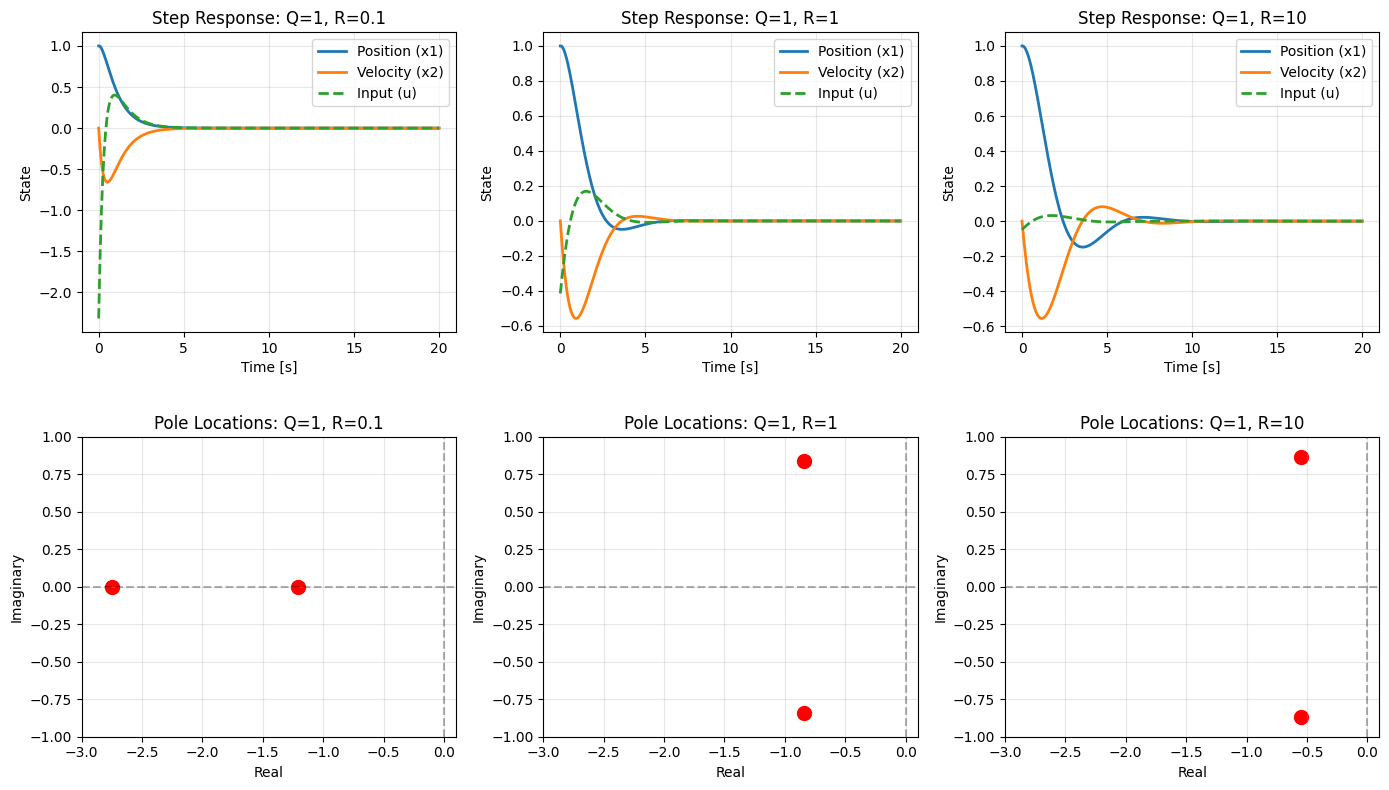

In [6]:
def simulate_system(A, B, C, K, time_end=10, initial_state=[1, 0]):
    # Closed-loop system dynamics (A_cl = A - B*K)
    A_cl = A - B @ K

    # Calculate the poles (eigenvalues of A_cl)
    poles = np.linalg.eigvals(A_cl)

    # Time vector
    t = np.linspace(0, time_end, 500)

    # Simulate the system's response to the initial state
    x = np.zeros((len(t), len(initial_state)))
    x[0] = initial_state

    for i in range(1, len(t)):
        # State update: x_dot = A_cl * x
        x_dot = A_cl @ x[i-1]
        x[i] = x[i-1] + x_dot * (t[i] - t[i-1])  # Simple Euler integration

    # Return state response, poles, and time vector
    return x, poles, t


# Define different values for Q and R weights to compare
Q_values = [1]  # Different state error weights (Q)
R_values = [0.1, 1, 10]  # Different input weights (R)

# Set up the plot grid based on number of Q and R values
plt.figure(figsize=(14, 8))
num_Q = len(Q_values)
num_R = len(R_values)


# Loop over combinations of Q and R
for i, Q_val in enumerate(Q_values):
    for j, R_val in enumerate(R_values):
        # Define Q and R
        Q = np.diag([Q_val, Q_val])  # State error weight
        R = np.array([[R_val]])      # Input weight

        # Compute the LQR gain K
        K = compute_lqr(A, B, Q, R)

        # Simulate the system and get the response and poles
        x, poles, t = simulate_system(A, B, C, K, time_end=20)

        # Compute input
        u = -K @ x.T

        # Create subplots for the system response (state variables)
        ax1 = plt.subplot(2, num_R, i*num_R + j + 1)
        ax1.plot(t, x[:, 0], label='Position (x1)', linewidth=2)
        ax1.plot(t, x[:, 1], label='Velocity (x2)', linewidth=2)
        ax1.plot(t, u[0, :], label='Input (u)', linewidth=2, linestyle='--')
        ax1.set_xlabel('Time [s]')
        ax1.set_ylabel('State')
        ax1.set_title(f'Step Response: Q={Q_val}, R={R_val}')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # Create subplots for the closed-loop poles in the complex plane
        ax2 = plt.subplot(2, num_R, num_R + i*num_R + j + 1)
        real_parts = np.real(poles)
        imag_parts = np.imag(poles)
        ax2.scatter(real_parts, imag_parts, color='r', s=100, label='Closed-loop Poles')
        ax2.axhline(0, color='k', linestyle='--', alpha=0.3)
        ax2.axvline(0, color='k', linestyle='--', alpha=0.3)
        ax2.set_xlabel('Real')
        ax2.set_ylabel('Imaginary')
        ax2.set_title(f'Pole Locations: Q={Q_val}, R={R_val}')
        ax2.grid(True, alpha=0.3)
        ax2.set_xlim((-3, 0.1))
        ax2.set_ylim((-1, 1))

# Adjust layout and display the plots
plt.tight_layout()
plt.subplots_adjust(hspace=0.35)
plt.show()

## Results and Interpretation

The results align with our intuition. The more negative the real part of the poles, the quicker the output converges to the reference. In the first case with the highest $\frac{Q}{R}$ ratio, we converge very fast and there is no oscillation. When choosing a high $R$, the input is punished more and the states oscillate more freely.

### Key Observations:
1. **Low R (R=0.1)**: Tight control, fast response, but requires large control inputs
2. **Medium R (R=1)**: Balanced approach between performance and effort
3. **High R (R=10)**: Conservative control, slower response, but uses smaller control inputs